# ARMA Model for Indian City Temperatures
## Goal
To build an ARMA (AutoRegressive Moving Average) model to analyse
temperature trends across 5 major Indian cities:
**Delhi, Mumbai, Bengaluru, Chennai and Kolkata**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import itertools
import warnings
warnings.filterwarnings('ignore')

## Data Loading & Preparation
We load daily temperature data for each city from CSV files.
Since we only have `Temp Max` and `Temp Min`, we calculate:

**Temp Mean = (Temp Max + Temp Min) / 2**

We also drop the `Rain` column as it is not needed for this model.

In [2]:
files = {
    'Delhi': 'delhi.csv',
    'Mumbai': 'mumbai.csv',
    'Bengaluru': 'bengaluru.csv',
    'Chennai': 'chennai.csv',
    'Kolkata': 'kolkata.csv'
}

city_data = {}

for city, fname in files.items():
    df = pd.read_csv(fname)
    df = df.drop(columns=['Rain'], errors='ignore')
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df['Temp Mean'] = (pd.to_numeric(df['Temp Max'], errors='coerce') +
                       pd.to_numeric(df['Temp Min'], errors='coerce')) / 2
    df = df.dropna(subset=['Date', 'Temp Mean'])
    df.set_index('Date', inplace=True)
    df = df.sort_index()[~df.index.duplicated()]
    city_data[city] = df['Temp Mean'].asfreq('D')

combined = pd.DataFrame(city_data).dropna()

print(combined.shape)
print(combined.head())

(26714, 5)
             Delhi  Mumbai  Bengaluru    Chennai  Kolkata
Date                                                     
1951-01-01  11.910  21.535  21.309999  24.630000   18.885
1951-01-02  12.640  21.665  20.435000  24.235000   17.280
1951-01-03  12.395  22.545  20.630000  23.675000   17.410
1951-01-04  12.850  22.250  20.785000  23.655000   18.350
1951-01-05  13.245  21.260  20.730000  23.485001   18.780


## Visualising Temperature Trends
Plotting the daily mean temperature for all 5 cities to get a 
feel for the data before building the model.

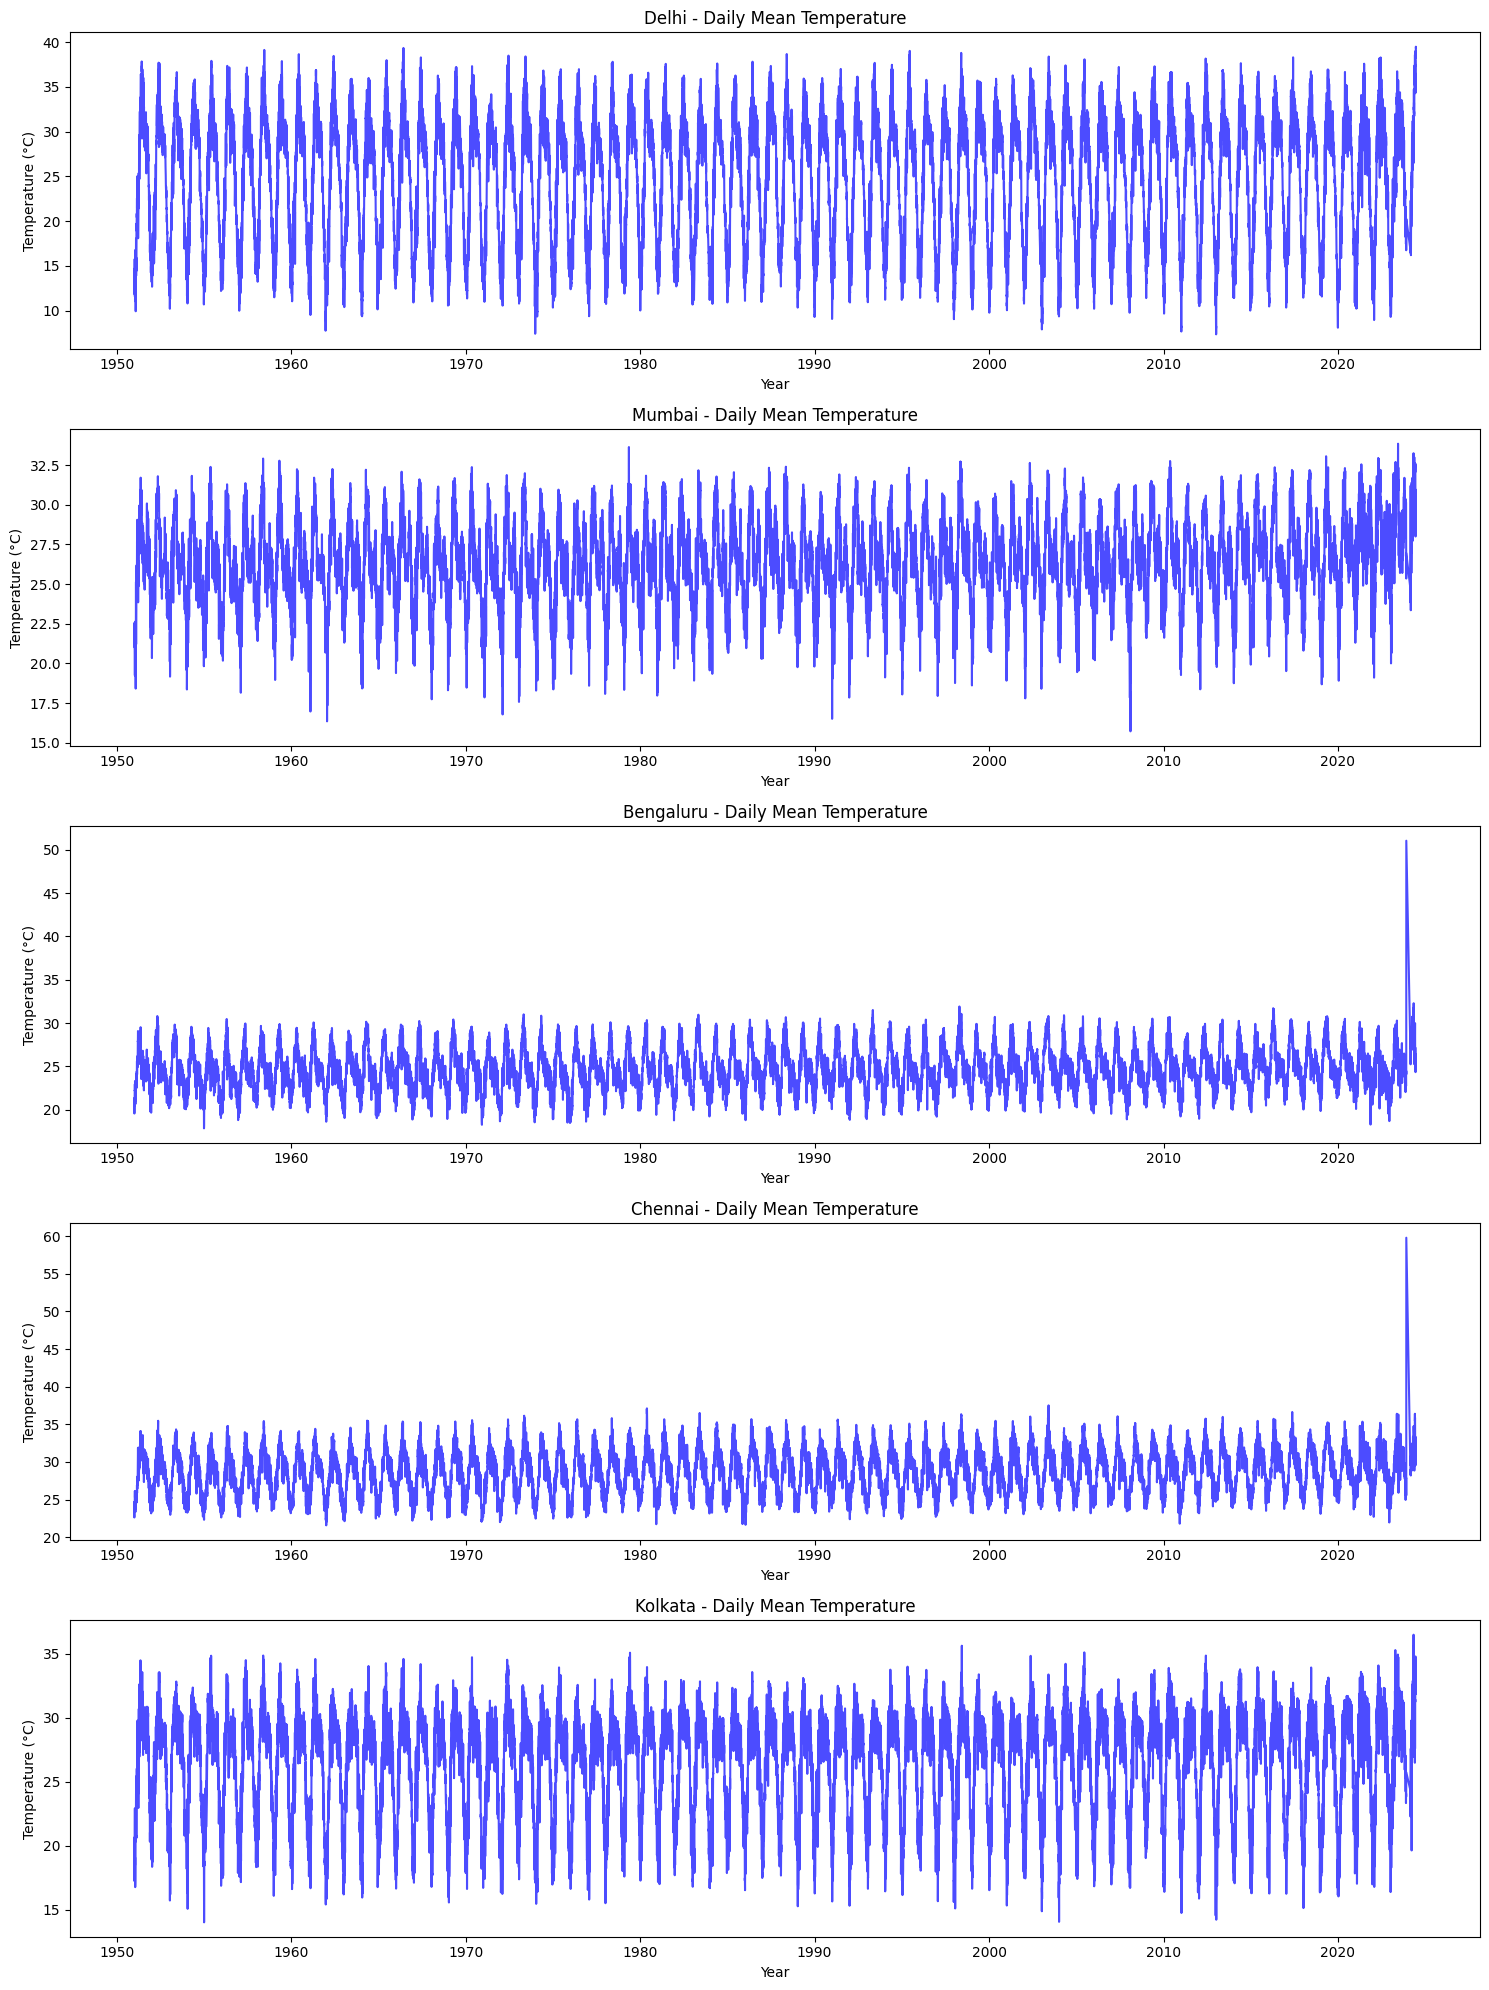

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(15, 20))

for ax, city in zip(axes, combined.columns):
    ax.plot(combined.index, combined[city], color='blue', alpha=0.7)
    ax.set_title(f'{city} - Daily Mean Temperature')
    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

### Observations
- **Delhi** shows the widest temperature swings — very hot summers and cold winters
- **Mumbai** stays warm and stable throughout the year (coastal city)
- **Bengaluru** has moderate temperatures due to its higher altitude
- **Chennai** is consistently warm being a coastal city
- **Kolkata** shows strong seasonal variation with very hot summers

### ⚠️ Data Quality Issue
Bengaluru and Chennai show abnormal spikes (~50-60°C) near 2024.
These are outliers (caused to wrong data entry) and will be removed before modelling.

In [4]:
combined = combined[(combined < 45) & (combined > 5)].dropna()

print(combined.shape)

(26713, 5)


## Stationarity Test (ADF Test)
Before building an ARMA model, the time series must be **stationary**, meaning:
- Mean is constant over time
- Standard deviation is constant over time
- No seasonality

We use the **Augmented Dickey-Fuller (ADF) Test** to check this.

**Interpretation:**
- If p-value < 0.05 → data IS stationary → we can use ARMA
- If p-value > 0.05 → data is NOT stationary → we need differencing (ARIMA)

In [5]:
for city in combined.columns:
    result = adfuller(combined[city].dropna())
    print(f'{city}')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.2e}')
    if result[1] < 0.05:
        print('Stationary — ARMA model can be applied')
    else:
        print('Not Stationary — ARIMA model can be applied')
    print()

Delhi
ADF Statistic : -19.6395
p-value       : 0.00e+00
Stationary — ARMA model can be applied

Mumbai
ADF Statistic : -19.6229
p-value       : 0.00e+00
Stationary — ARMA model can be applied

Bengaluru
ADF Statistic : -19.2904
p-value       : 0.00e+00
Stationary — ARMA model can be applied

Chennai
ADF Statistic : -16.2669
p-value       : 3.52e-29
Stationary — ARMA model can be applied

Kolkata
ADF Statistic : -18.9842
p-value       : 0.00e+00
Stationary — ARMA model can be applied



## Understanding the ADF Test Results

### What is the ADF Test?
The ADF (Augmented Dickey-Fuller) test is a **hypothesis test** that checks 
whether a time series is stationary or not.

| | Hypothesis Test | ADF Test |
|--|--|--|
| **Null Hypothesis (H₀)** | Default assumption | Data is NOT stationary |
| **Alternative Hypothesis (H₁)** | What we want to prove | Data IS stationary |
| **p-value** | Probability H₀ is true | Probability data is non-stationary |
| **Decision** | p < 0.05 → reject H₀ | p < 0.05 → data is stationary ✅ |

---

### What does the p-value mean?
The p-value tells you how likely the null hypothesis is true.

| p-value | Meaning |
|---------|---------|
| > 0.05 | Cannot reject — data is likely non-stationary |
| < 0.05 | Reject null hypothesis — data is stationary |
| ~0 | Extremely stationary — very strong evidence |

---

### What does Stationary mean?
A time series is **stationary** if it behaves the same way throughout time.
There are 3 conditions:

1. **Constant Mean** — the average doesn't drift up or down over time
2. **Constant Variance** — the ups and downs stay the same size over time
3. **No Seasonality** — no predictable repeating pattern

> **One line summary:** Stationary = the data's behaviour doesn't change over time

---

### Our Results:
| City | ADF Statistic | p-value | Stationary? |
|------|--------------|---------|-------------|
| Delhi | -19.64 | ~0 | Yes |
| Mumbai | -19.62 | ~0 | Yes |
| Bengaluru | -19.29 | ~0 | Yes |
| Chennai | -16.27 | 3.52e-29 | Yes |
| Kolkata | -18.98 | ~0 | Yes |

All 5 cities are stationary — we can safely apply the ARMA model.

## Building the ARMA Model
Since all cities are stationary, we can use an **ARMA model**.

ARMA has two components:
- **AR (AutoRegressive)** → uses past values to predict the future
  - e.g. "yesterday's temperature helps predict today's"
- **MA (Moving Average)** → uses past errors to correct future predictions
  - e.g. "if I was wrong yesterday, adjust today's prediction"

The model is written as **ARMA(p, q)** where:
- **p** = number of past values to look at (AR part)
- **q** = number of past errors to look at (MA part)

We use ARIMA with **d=0** (no differencing needed since data is stationary)

In [6]:
results = {}

for city in combined.columns:
    ts = combined[city].dropna()
    
    # ARMA(1,1) — start simple, p=1, d=0, q=1
    model = ARIMA(ts, order=(1, 0, 1))
    fitted = model.fit()
    results[city] = fitted
    
    print(f'{city}')
    print(f'AIC: {fitted.aic:.2f}')
    print()

Delhi
AIC: 82073.54

Mumbai
AIC: 56902.59

Bengaluru
AIC: 53365.60

Chennai
AIC: 58162.99

Kolkata
AIC: 71531.26



## ARMA(1,1) Results

We started with a simple **ARMA(1,1)** model for all cities as a baseline.
This will be improved later using grid search.

### AIC Scores Summary:
| City | AIC (ARMA 1,1) | Interpretation |
|------|---------------|----------------|
| Delhi | 82073.54 | Highest — model finds Delhi hardest to fit |
| Kolkata | 71531.26 | |
| Chennai | 58162.99 | |
| Mumbai | 56902.59 | |
| Bengaluru | 53365.60 | Lowest — best fit so far |

### What is AIC?
- **AIC (Akaike Information Criterion)** measures how well the model fits the data
- **Lower AIC = Better model**
- We used ARMA(1,1) for all cities as a starting point
- In the grid search step, we'll find the best p and q for each city 
individually to bring these scores down

### Observation
Delhi's AIC is noticeably higher than the rest, likely because its temperature 
swings are the most extreme and complex to model with simple ARMA(1,1).

## Model Evaluation (MAE)
Now we check how accurate our ARMA(1,1) model is using **MAE (Mean Absolute Error)**.

### What is MAE?
- MAE measures the **average difference** between predicted and actual temperatures
- e.g. MAE = 2.5 means our predictions are off by **2.5°C on average**
- **Lower MAE = Better model**

### How we evaluate:
- We train the model on data up to **2020**
- We test it on data from **2021 to 2024**
- This way we check if the model can predict temperatures it has never seen before

In [7]:
for city in combined.columns:
    ts = combined[city].dropna()
    
    # split into train and test
    train = ts[ts.index < '2021-01-01']
    test  = ts[ts.index >= '2021-01-01']
    
    # fit model on training data
    model = ARIMA(train, order=(1, 0, 1))
    fitted = model.fit()
    
    # predict on test period
    predictions = fitted.predict(start=len(train), end=len(ts)-1)
    
    # calculate MAE
    mae = mean_absolute_error(test, predictions)
    
    print(f'{city}')
    print(f'Test period  : 2021 to 2024 ({len(test)} days)')
    print(f'MAE          : {mae:.2f} °C')
    print()

Delhi
Test period  : 2021 to 2024 (1148 days)
MAE          : 5.86 °C

Mumbai
Test period  : 2021 to 2024 (1148 days)
MAE          : 2.56 °C

Bengaluru
Test period  : 2021 to 2024 (1148 days)
MAE          : 1.78 °C

Chennai
Test period  : 2021 to 2024 (1148 days)
MAE          : 2.25 °C

Kolkata
Test period  : 2021 to 2024 (1148 days)
MAE          : 3.65 °C



## ARMA(1,1) Evaluation Results

### MAE Summary — ARMA(1,1) Baseline:
| City | MAE | Interpretation |
|------|-----|----------------|
| Delhi | 5.86°C | Poor — predictions off by almost 6°C on average |
| Kolkata | 3.65°C | Moderate |
| Mumbai | 2.56°C | Decent |
| Chennai | 2.25°C | Decent |
| Bengaluru | 1.78°C | Best so far |

### Observations:
- **Bengaluru and Chennai** are performing well — stable temperatures are easier to predict
- **Mumbai and Kolkata** are moderate — acceptable but can be improved
- **Delhi is struggling** — its extreme seasonal swings (10°C in winter to 40°C 
in summer) make it the hardest to predict with a simple ARMA(1,1)

### Why does this matter?
Using the same ARMA(1,1) for all cities is too simplistic. Each city has a 
different temperature pattern and needs its own best p and q values.
This is what the grid search in the next step will solve.

## Model Tuning — Grid Search
Our ARMA(1,1) was just a starting point. Now we find the **best p and q** 
for each city individually using a grid search.

### How Grid Search works:
- We try every combination of p and q from 0 to 3
- For each combination we fit an ARMA model and record its **AIC score**
- The combination with the **lowest AIC** is the best model for that city

### Why AIC and not MAE?
- AIC is faster to compute during grid search — we don't need to split 
train/test for every combination
- Once we find the best p and q using AIC, we then confirm with MAE

In [8]:
best_orders = {}

for city in combined.columns:
    ts = combined[city].dropna()
    
    # train/test split
    train = ts[ts.index < '2021-01-01']
    test  = ts[ts.index >= '2021-01-01']
    
    best_mae = float('inf')
    best_order = None
    
    for p, q in itertools.product(range(4), range(4)):
        try:
            model = ARIMA(train, order=(p, 0, q))
            fitted = model.fit()
            predictions = fitted.predict(start=len(train), end=len(ts)-1)
            mae = mean_absolute_error(test, predictions)
            
            if mae < best_mae:
                best_mae = mae
                best_order = (p, q)
        except:
            continue
    
    best_orders[city] = best_order
    print(f'Best for {city} : ARMA{best_order} - MAE: {best_mae:.2f}')
    print()

Best for Delhi : ARMA(3, 3) - MAE: 5.82

Best for Mumbai : ARMA(0, 0) - MAE: 2.55

Best for Bengaluru : ARMA(1, 0) - MAE: 1.78

Best for Chennai : ARMA(3, 0) - MAE: 2.25

Best for Kolkata : ARMA(3, 3) - MAE: 3.57



## MAE-Based Grid Search Results

### Best Orders Found:
| City | Best Order | Best MAE | Interpretation |
|------|------------|----------|----------------|
| Delhi | ARMA(3,3) | 5.82 | Complex seasonal swings need more history |
| Mumbai | ARMA(0,0) | 2.55 | Temperature is stable — no past values needed |
| Bengaluru | ARMA(1,0) | 1.78 | Simple AR model is sufficient |
| Chennai | ARMA(3,0) | 2.25 | Pure AR model, no MA component needed |
| Kolkata | ARMA(3,3) | 3.57 | Complex patterns need more history |

### Comparison with ARMA(1,1) Baseline:
| City | ARMA(1,1) MAE | Best MAE | Change |
|------|--------------|----------|--------|
| Delhi | 5.86 | 5.82 | -0.04 tiny improvement |
| Mumbai | 2.56 | 2.55 | -0.01 basically the same |
| Bengaluru | 1.78 | 1.78 | no change |
| Chennai | 2.25 | 2.25 | no change |
| Kolkata | 3.65 | 3.57 | -0.08 slight improvement |

### Why did MAE barely improve?
Daily temperature data has very strong seasonality which ARMA struggles 
to fully capture. ARMA works best on data without strong seasonal patterns.

### Key Insight — ARMA(0,0) for Mumbai:
Mumbai's temperature is so stable that past values and past errors do not 
help predict it any better than simply using the mean temperature. This is 
consistent with Mumbai being a coastal city with very low temperature variation.

## Project Summary

### Title
Detection of Climate Change Signals in Indian Temperature Records Using 
Probability Theory and Moving Average Processes for Anomaly Identification 
and Trend Analysis

---

### Dataset
Daily temperature records for 5 Indian cities — Delhi, Mumbai, Bengaluru, 
Chennai and Kolkata — spanning 1951 to 2024 (26,000+ observations per city).

---

### What We Did
1. **Loaded and cleaned the data** — computed Temp Mean from Temp Max and 
Temp Min, dropped Rain column, removed outliers (spikes above 45 degrees C)

2. **Visualised the data** — plotted 5 separate graphs showing 70 years of 
daily temperature for each city

3. **Tested for stationarity** — ran the ADF test on all 5 cities. All passed 
with p-values close to zero, confirming ARMA can be applied

4. **Built a baseline ARMA(1,1) model** — fitted a simple model for all cities 
as a starting point

5. **Evaluated with MAE** — tested predictions on 2021 to 2024 data. Delhi 
performed worst (5.86 C) and Bengaluru best (1.78 C)

6. **Ran MAE-based grid search** — tested all combinations of p and q from 
0 to 3 to find the best model per city

7. **Re-evaluated with best orders** — marginal improvements confirmed ARMA's 
limitation with strongly seasonal data

---

### Final Results
| City | Best Model | Final MAE |
|------|-----------|-----------|
| Delhi | ARMA(3,3) | 5.82 C |
| Mumbai | ARMA(0,0) | 2.55 C |
| Bengaluru | ARMA(1,0) | 1.78 C |
| Chennai | ARMA(3,0) | 2.25 C |
| Kolkata | ARMA(3,3) | 3.57 C |

---

### Key Limitation
ARMA cannot fully capture strong seasonal patterns in daily temperature data. 
A seasonal model like SARIMA would perform significantly better but is beyond 
the scope of this project.